# 1. Importação das bibliotecas do projeto

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("✅ Ambiente configurado com sucesso!")

✅ Ambiente configurado com sucesso!


# 2. Importação do dataset

Nesta etapa, o conjunto de dados será carregado para o ambiente Python. Após a importação, serão feitas verificações iniciais para confirmar que os dados foram lidos corretamente e estão prontos para as próximas análises.

In [18]:
df = pd.read_csv("data/manutencao_preditiva.csv")

In [19]:
# Visualizar as cinco primeiras linhas do dataset
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [20]:
# Verificar o tamanho do dataset
df.shape

(10000, 14)

In [21]:
# Exibir informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8), str(2)
me

In [22]:
# Verificar valores ausentes em cada coluna
df.isnull().sum()

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

In [23]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [24]:
# Exibir o nome de todas as colunas
df.columns

Index(['udi', 'id_produto', 'tipo', 'temperatura_ar_k',
       'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm',
       'desgaste_ferramenta_min', 'falha_maquina', 'falha_twf', 'falha_hdf',
       'falha_pwf', 'falha_osf', 'falha_rnf'],
      dtype='str')

# 3. Análise Exploratória dos Dados (EDA)

Nesta etapa, será realizada uma exploração inicial do conjunto de dados para compreender sua estrutura, identificar possíveis inconsistências e analisar as características das variáveis antes da construção dos modelos de Inteligência Artificial.

In [25]:
## 3.1 Verificar registros duplicados
df.duplicated().sum()

np.int64(0)

**Interpretação:**

A verificação identificou que o conjunto de dados não possui registros duplicados. Isso indica que cada observação é única, não sendo necessário remover linhas duplicadas antes das próximas etapas da análise.

In [26]:
## 3.2 Contagem da variável alvo
df["falha_maquina"].value_counts()

falha_maquina
0    9661
1     339
Name: count, dtype: int64

Interpretação:

A variável alvo `falha_maquina` apresenta 9.661 registros de funcionamento normal (classe 0) e 339 registros de falha mecânica (classe 1). Essa diferença indica que o conjunto de dados está desbalanceado, pois há muito mais exemplos de máquinas operando normalmente do que de máquinas com falha.

Esse resultado é importante porque a variável `falha_maquina` é o alvo que será previsto pelos modelos. Nas próximas etapas, será necessário considerar esse desbalanceamento ao preparar os dados de treino.

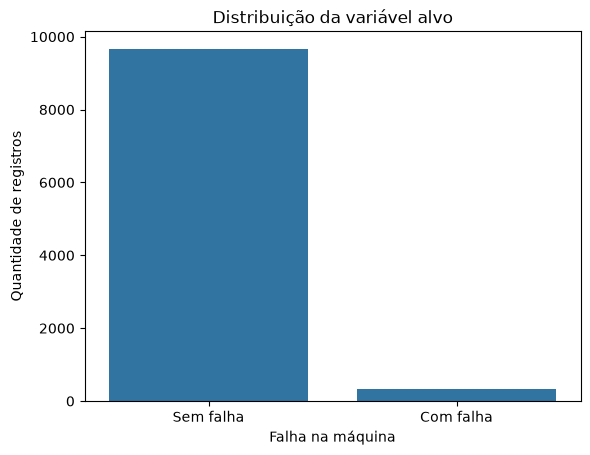

In [27]:
## 3.3 Gráfico de barras da variável alvo

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="falha_maquina")
plt.title("Distribuição da variável alvo")
plt.xlabel("Falha na máquina")
plt.ylabel("Quantidade de registros")
plt.xticks([0, 1], ["Sem falha", "Com falha"])
plt.show()

Interpretação:

O gráfico mostra que a variável alvo apresenta um desbalanceamento entre as classes. A maior parte dos registros corresponde a máquinas operando normalmente, enquanto uma quantidade bem menor representa ocorrências de falha.

Essa característica deverá ser considerada durante o desenvolvimento do modelo preditivo, pois pode influenciar o desempenho dos algoritmos de classificação. Na etapa de modelagem será avaliada a necessidade de aplicar técnicas específicas para lidar com esse desbalanceamento.

## 3.4 Histograma das variáveis numéricas

Nesta etapa, serão analisadas as distribuições das principais variáveis numéricas do conjunto de dados. Essa visualização permite compreender a concentração dos valores, identificar possíveis assimetrias e observar o comportamento geral dos dados antes da etapa de preparação para a modelagem.

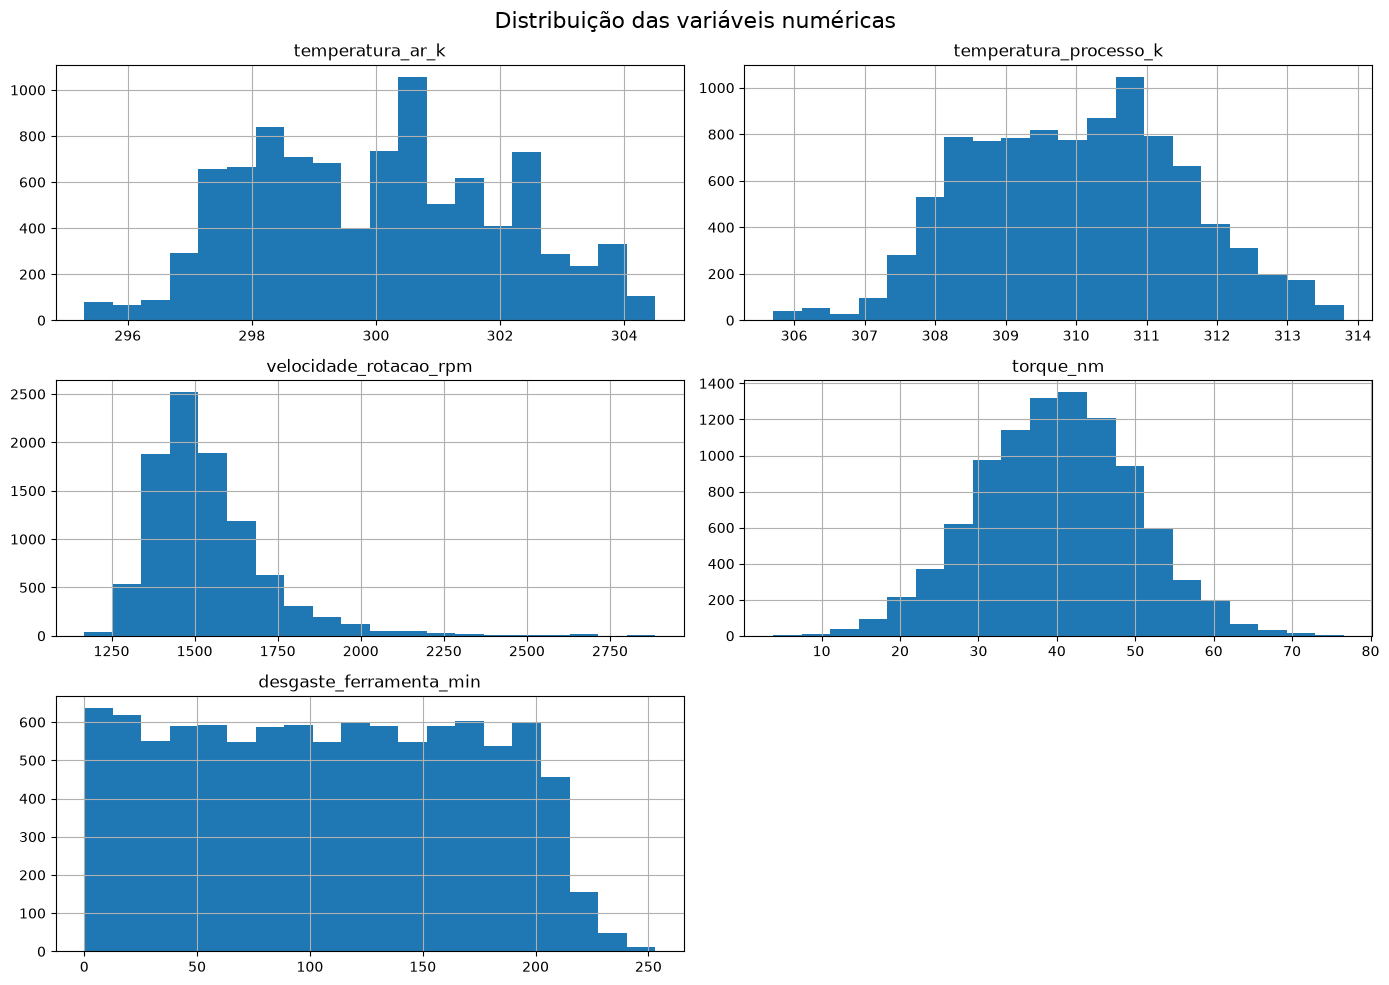

In [28]:
# Histogramas das variáveis numéricas preditoras

colunas_numericas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

df[colunas_numericas].hist(figsize=(14, 10), bins=20)

plt.suptitle("Distribuição das variáveis numéricas", fontsize=16)
plt.tight_layout()

plt.show()

Interpretação:

Os histogramas mostram que as variáveis numéricas apresentam distribuições distintas. As temperaturas do ar e do processo possuem comportamento próximo de uma distribuição normal, enquanto a velocidade de rotação apresenta maior concentração em valores mais baixos e uma cauda à direita.

O torque também apresenta distribuição aproximadamente simétrica. Já o desgaste da ferramenta está distribuído em uma ampla faixa de valores, indicando diferentes níveis de utilização dos equipamentos.

Essa análise auxilia na compreensão do comportamento das variáveis antes da etapa de preparação dos dados e construção dos modelos preditivos.

## 3.5 Mapa de calor da correlação entre as variáveis

Nesta etapa, será analisada a correlação entre as variáveis numéricas do conjunto de dados utilizando o coeficiente de correlação de Pearson. O mapa de calor permite identificar relações positivas ou negativas entre as variáveis, auxiliando na compreensão dos dados antes da construção dos modelos preditivos.

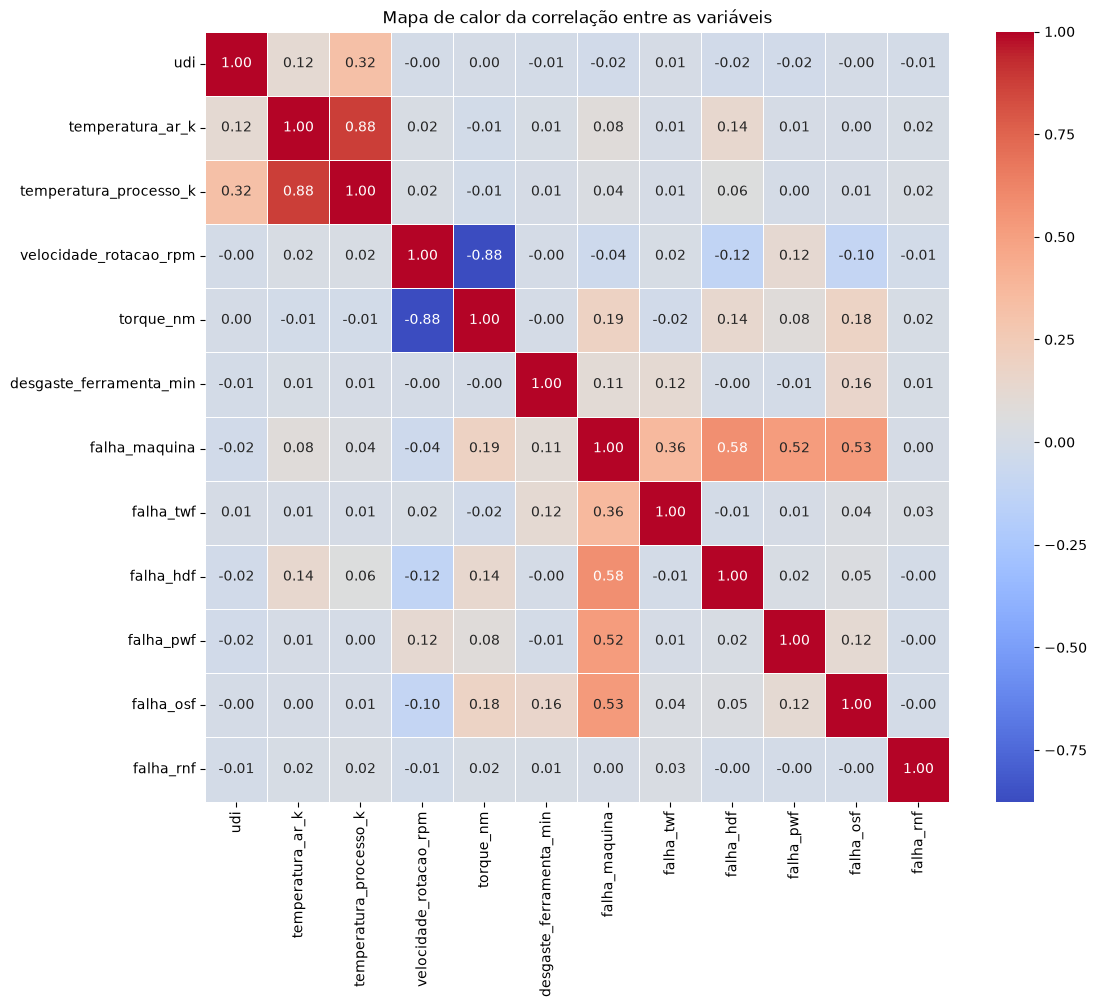

In [29]:
# Mapa de calor da correlação entre as variáveis numéricas

plt.figure(figsize=(12, 10))

matriz_correlacao = df.corr(numeric_only=True)

sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de calor da correlação entre as variáveis")
plt.show()

**Interpretação:**

O mapa de calor mostra que a maioria das variáveis apresenta baixa correlação linear entre si, indicando que cada sensor fornece informações distintas sobre o funcionamento da máquina.

Destacam-se a forte correlação positiva entre a temperatura do ar e a temperatura do processo (0,88) e a forte correlação negativa entre a velocidade de rotação e o torque (-0,88), evidenciando relações físicas esperadas no funcionamento dos equipamentos.

Em relação à variável alvo, observam-se correlações moderadas com alguns tipos específicos de falha (HDF, OSF e PWF), enquanto as demais variáveis apresentam correlação linear fraca. Esse resultado reforça a importância da utilização de algoritmos de aprendizado de máquina para identificar padrões mais complexos que não podem ser explicados apenas por relações lineares entre as variáveis.

# 4 Limpeza e Tratamento de Dados (Data Prep)

## 4.1 Identificar linhas duplicadas

In [32]:
df.duplicated().sum()

np.int64(0)

## 4.2 Remover duplicados

In [33]:
df = df.drop_duplicates()
df.shape

(10000, 14)

## 4.3 Identificar dados ausentes

In [34]:
df.isnull().sum()

udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64

## 4.4 Boxplot

Uso de gráficos tipo boxplot para identificar a possível presença de outliers nas variáveis explicativas.

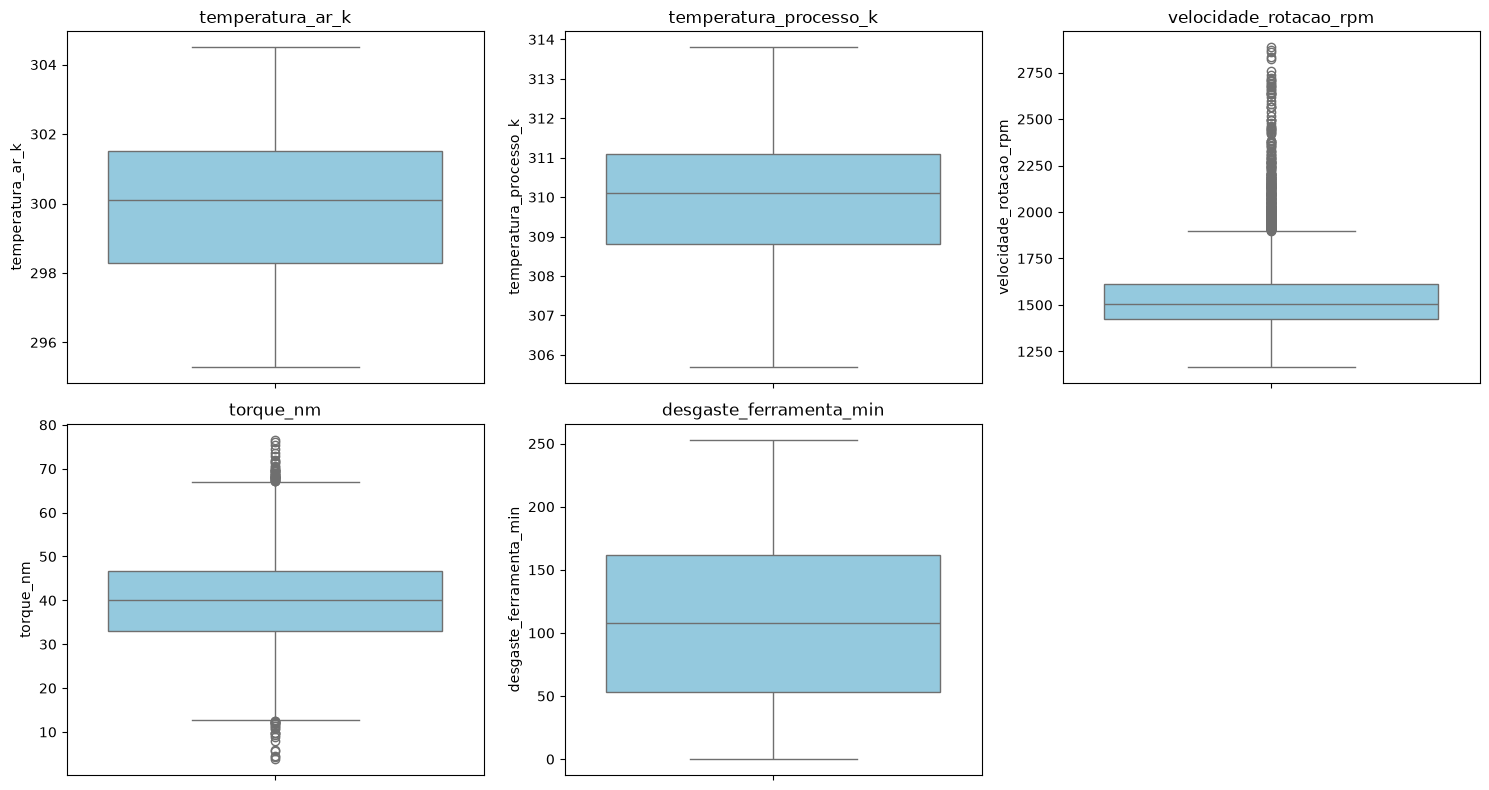

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

colunas_numericas = [
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(y=df[coluna], ax=axes[i], color="skyblue")
    axes[i].set_title(coluna)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

Interpretação:

Os boxplots indicam que velocidade_rotacao_rpm e torque_nm apresentam maior quantidade de valores extremos, enquanto as variáveis de temperatura estão mais concentradas. Esse comportamento reforça a necessidade de tratamento cuidadoso dos dados antes da modelagem, especialmente na escolha da medida de imputação e na interpretação das distribuições